# Compresión de los datos 

## Diccionario

| Nombre de columna | Descripción | Tipo de dato |
|---|---|---|
| student_id | Identificador único del estudiante | int64 |
| age | Edad del estudiante (en años) | int64 |
| gender | Género del estudiante (categoría: probablemente M/F u otra) | object |
| study_hours_per_day | Horas dedicadas al estudio por día | float64 |
| sleep_hours | Horas de sueño por día | float64 |
| phone_usage_hours | Horas de uso del teléfono por día | float64 |
| social_media_hours | Horas dedicadas a redes sociales por día | float64 |
| youtube_hours | Horas dedicadas a YouTube por día | float64 |
| gaming_hours | Horas dedicadas a videojuegos por día | float64 |
| breaks_per_day | Número de descansos tomados durante el día | int64 |
| coffee_intake_mg | Consumo de cafeína en miligramos por día | int64 |
| exercise_minutes | Minutos de ejercicio por día | int64 |
| assignments_completed | Número de tareas completadas en un período determinado | int64 |
| attendance_percentage | Porcentaje de asistencia a clases | float64 |
| stress_level | Nivel de estrés (escala numérica, probablemente 1-10 o similar) | int64 |
| focus_score | Puntaje de capacidad de concentración (escala numérica) | int64 |
| final_grade | Calificación final obtenida | float64 |
| productivity_score | Puntaje de productividad (variable objetivo original del dataset) | float64 |

Fuente: adaptado de la descripción del dataset "Student Productivity and Distraction" (Kaggle, CC0).

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv('../data/raw/student_productivity_distraction_dataset_20000.csv')


In [6]:
display(df.iloc[:, :10].head())


,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day
0,1,23,Female,4.35,3.63,3.38,2.73,1.83,5.26,6
1,2,20,Male,6.14,6.58,5.48,1.51,3.13,1.73,13
2,3,29,Female,4.98,3.26,4.83,3.63,0.18,4.71,1
3,4,27,Female,3.19,4.58,10.06,3.95,5.75,2.52,9
4,5,24,Male,7.67,6.21,3.02,1.59,5.46,5.65,8


In [7]:
df.columns.tolist()

['student_id',
 'age',
 'gender',
 'study_hours_per_day',
 'sleep_hours',
 'phone_usage_hours',
 'social_media_hours',
 'youtube_hours',
 'gaming_hours',
 'breaks_per_day',
 'coffee_intake_mg',
 'exercise_minutes',
 'assignments_completed',
 'attendance_percentage',
 'stress_level',
 'focus_score',
 'final_grade',
 'productivity_score']

In [8]:
df.dtypes


student_id                 int64
age                        int64
gender                    object
study_hours_per_day      float64
sleep_hours              float64
phone_usage_hours        float64
social_media_hours       float64
youtube_hours            float64
gaming_hours             float64
breaks_per_day             int64
coffee_intake_mg           int64
exercise_minutes           int64
assignments_completed      int64
attendance_percentage    float64
stress_level               int64
focus_score                int64
final_grade              float64
productivity_score       float64
dtype: object

In [11]:
df.shape

(20000, 18)

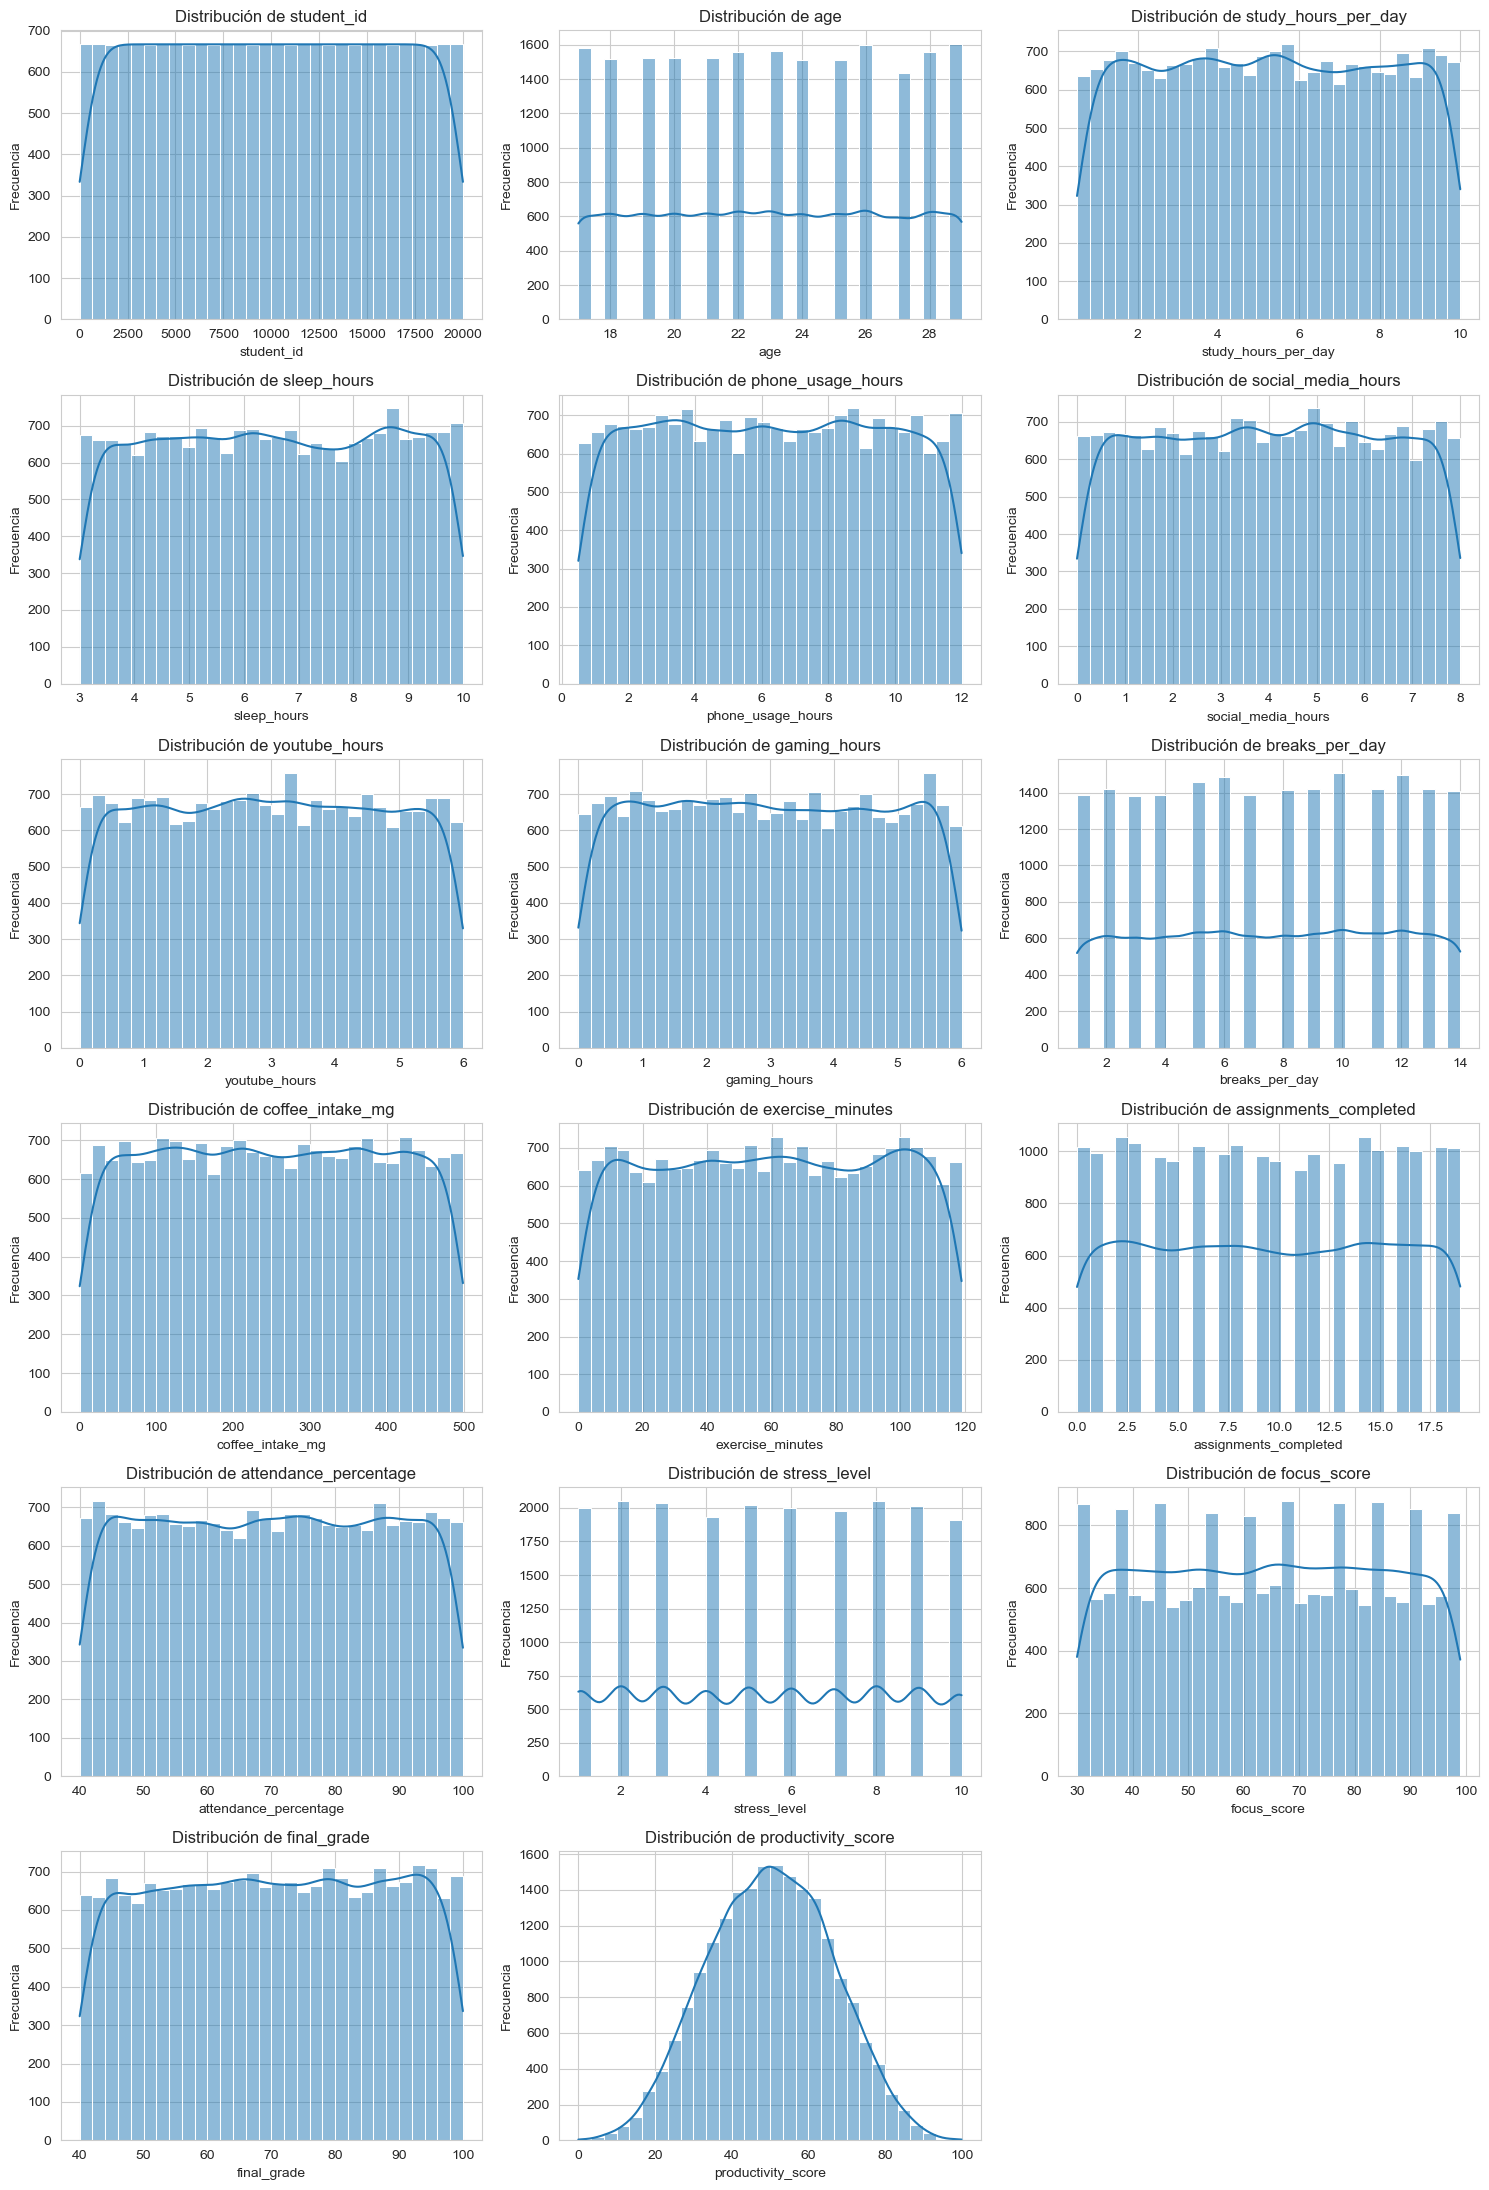

In [9]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
fig, axes = plt.subplots(nrows=len(numeric_cols)//3 + 1, ncols=3, figsize=(15, 4*len(numeric_cols)//3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], bins=30)
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

for i in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [10]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

if len(cat_cols) > 0:
    fig, axes = plt.subplots(nrows=len(cat_cols), ncols=1, figsize=(10, 5*len(cat_cols)))
    if len(cat_cols) == 1:
        axes = [axes]
    
    for i, col in enumerate(cat_cols):
        sns.countplot(data=df, x=col, ax=axes[i])
        axes[i].set_title(f'Distribución de {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frecuencia')
        axes[i].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
else:
    display("No hay variables categóricas de tipo object en el dataset.")Variable	N° Outliers	% Outliers	Límite inferior	Límite superior
0	student_id	0	0.00	-9998.50	29999.50
1	age	0	0.00	11.00	35.00
2	study_hours_per_day	0	0.00	-4.21	14.75
3	sleep_hours	0	0.00	-0.54	13.62
4	phone_usage_hours	0	0.00	-5.20	17.69
5	social_media_hours	0	0.00	-3.96	11.92
6	youtube_hours	0	0.00	-3.00	8.97
7	gaming_hours	0	0.00	-3.01	8.99
8	breaks_per_day	0	0.00	-6.50	21.50
9	coffee_intake_mg	0	0.00	-247.00	745.00
10	exercise_minutes	0	0.00	-60.00	180.00
11	assignments_completed	0	0.00	-12.50	31.50
12	attendance_percentage	0	0.00	9.45	130.41
13	stress_level	0	0.00	-4.50	15.50
14	focus_score	0	0.00	-5.50	134.50
15	final_grade	0	0.00	10.64	130.16
16	productivity_score	18	0.09	4.08	96.41
|

SyntaxError: invalid character '°' (U+00B0) (1767916224.py, line 18)

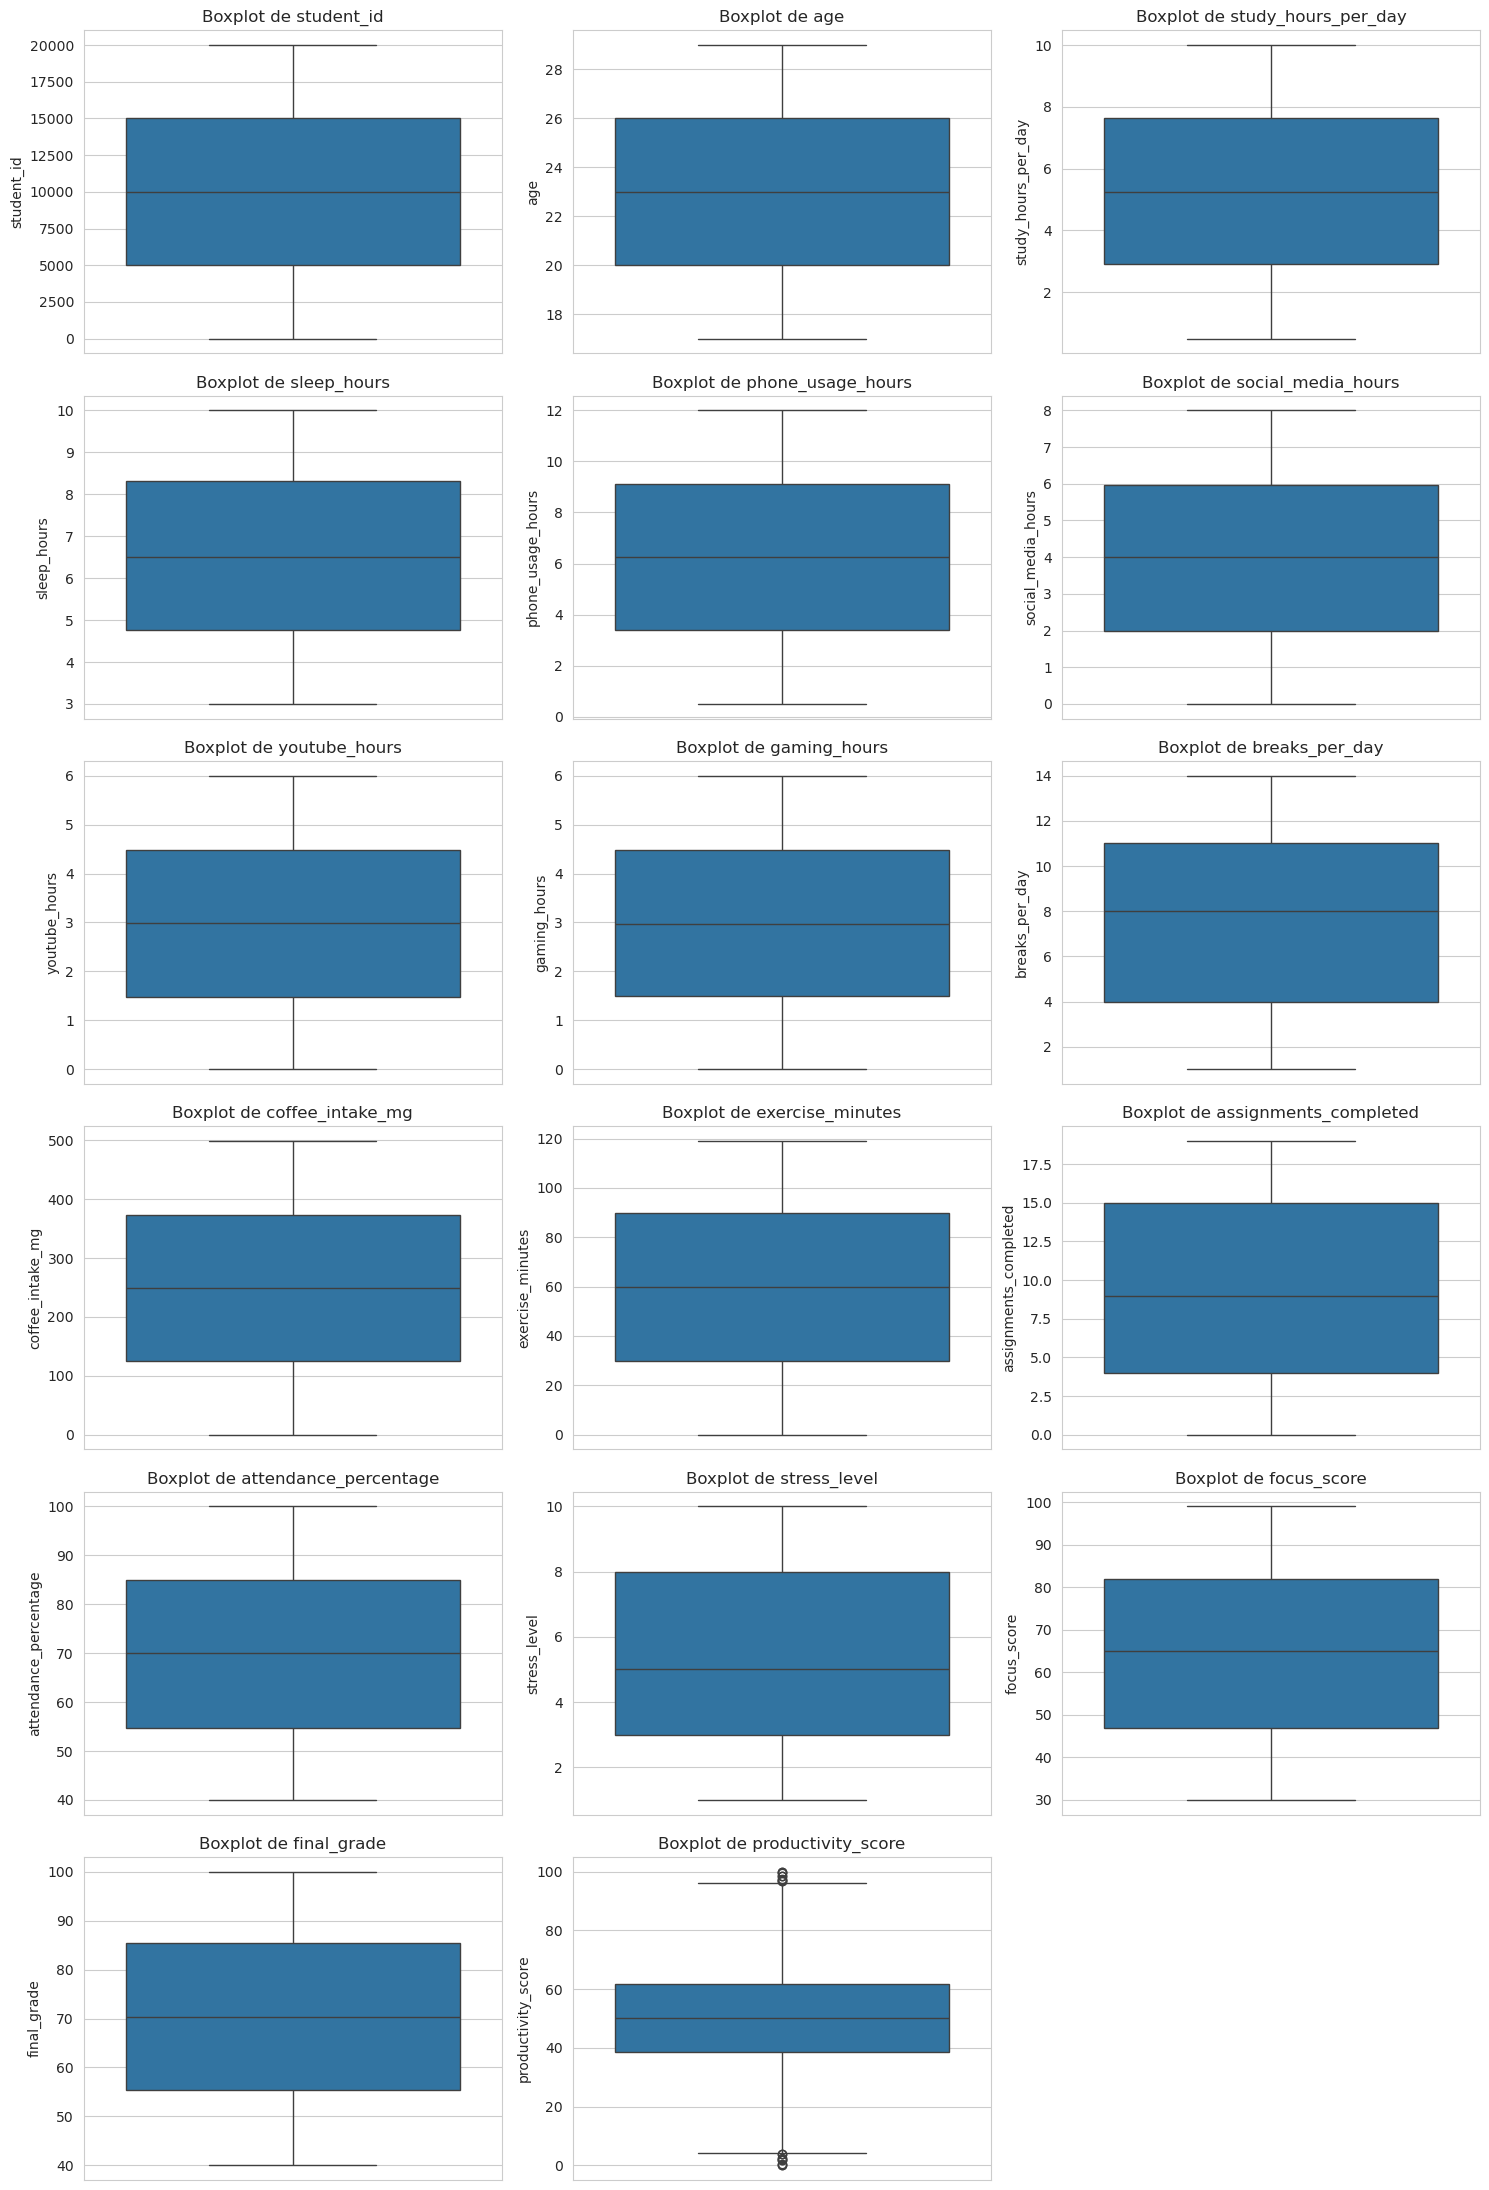

In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

fig, axes = plt.subplots(nrows=len(numeric_cols)//3 + 1, ncols=3, figsize=(15, 4*len(numeric_cols)//3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot de {col}')
    axes[i].set_ylabel(col)

for i in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
null_counts = df[numeric_cols].isnull().sum()
display(null_counts)

student_id               0
age                      0
study_hours_per_day      0
sleep_hours              0
phone_usage_hours        0
social_media_hours       0
youtube_hours            0
gaming_hours             0
breaks_per_day           0
coffee_intake_mg         0
exercise_minutes         0
assignments_completed    0
attendance_percentage    0
stress_level             0
focus_score              0
final_grade              0
productivity_score       0
dtype: int64

In [ ]:
null_df = pd.DataFrame({
    'Variable': null_counts.index,
    'Nulos': null_counts.values,
    '% Nulos': (null_counts.values / len(df) * 100).round(2)
})
display(null_df)

,Variable,Nulos,% Nulos
0,student_id,0,0.0
1,age,0,0.0
2,study_hours_per_day,0,0.0
3,sleep_hours,0,0.0
4,phone_usage_hours,0,0.0
5,social_media_hours,0,0.0
6,youtube_hours,0,0.0
7,gaming_hours,0,0.0
8,breaks_per_day,0,0.0
9,coffee_intake_mg,0,0.0


In [ ]:
cat_cols = df.select_dtypes(include=['object']).columns
null_counts_cat = df[cat_cols].isnull().sum()

null_cat_df = pd.DataFrame({
    'Variable': null_counts_cat.index,
    'Nulos': null_counts_cat.values,
    '% Nulos': (null_counts_cat.values / len(df) * 100).round(2)
})
display(null_cat_df)

,Variable,Nulos,% Nulos
0,gender,0,0.0


In [ ]:
def count_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

outliers_summary = []
for col in numeric_cols:
    n_outliers, lb, ub = count_outliers_iqr(df, col)
    outliers_summary.append({
        'Variable': col,
        'N° Outliers': n_outliers,
        '% Outliers': round(100 * n_outliers / len(df), 2),
        'Límite inferior': round(lb, 2),
        'Límite superior': round(ub, 2)
    })

outliers_df = pd.DataFrame(outliers_summary)
display(outliers_df)

,Variable,N° Outliers,% Outliers,Límite inferior,Límite superior
0,student_id,0,0.00,-9998.50,29999.50
1,age,0,0.00,11.00,35.00
2,study_hours_per_day,0,0.00,-4.21,14.75
3,sleep_hours,0,0.00,-0.54,13.62
4,phone_usage_hours,0,0.00,-5.20,17.69
5,social_media_hours,0,0.00,-3.96,11.92
6,youtube_hours,0,0.00,-3.00,8.97
7,gaming_hours,0,0.00,-3.01,8.99
8,breaks_per_day,0,0.00,-6.50,21.50
9,coffee_intake_mg,0,0.00,-247.00,745.00


In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'student_id' in numeric_cols:
    numeric_cols.remove('student_id')

pearson_corr = df[numeric_cols].corrwith(df['stress_level']).sort_values(ascending=False)

spearman_corr = df[numeric_cols].corrwith(df['stress_level'], method='spearman').sort_values(ascending=False)

corr_df = pd.DataFrame({
    'Pearson': pearson_corr,
    'Spearman': spearman_corr
})

display(corr_df)

,Pearson,Spearman
age,-0.002612,-0.002637
assignments_completed,0.016411,0.016436
attendance_percentage,-0.005931,-0.005931
breaks_per_day,0.002395,0.002386
coffee_intake_mg,-0.008850,-0.008846
exercise_minutes,0.009474,0.009486
final_grade,-0.012216,-0.012043
focus_score,-0.007501,-0.007455
gaming_hours,0.001791,0.001709
phone_usage_hours,0.006138,0.006158


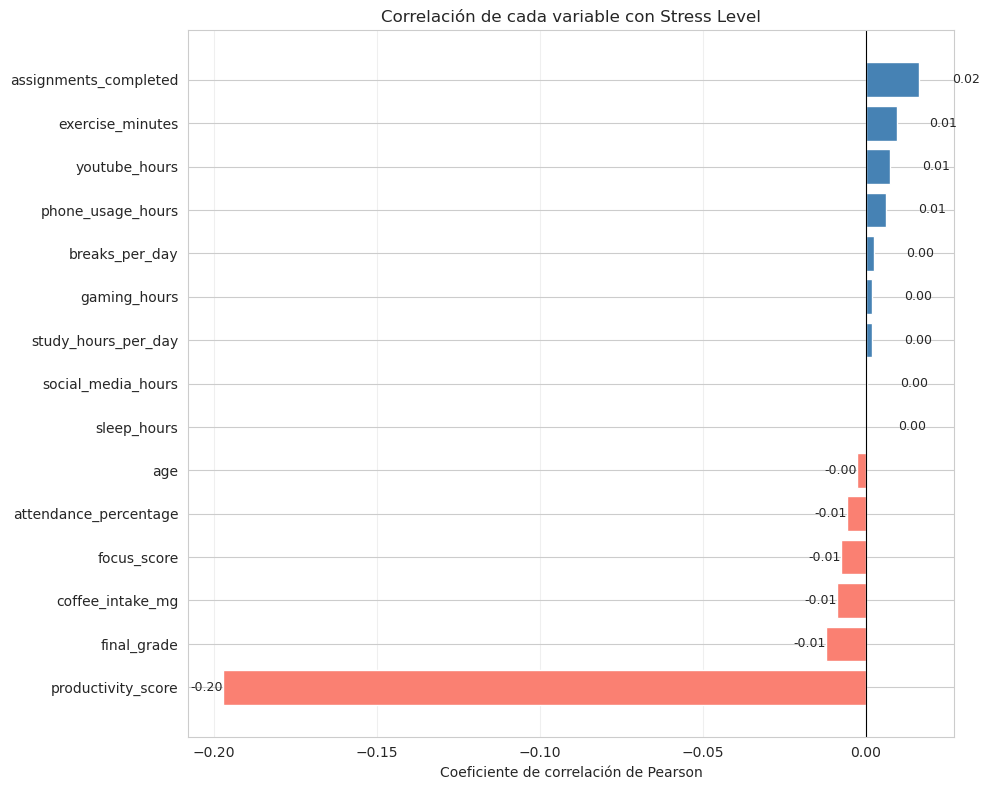

In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'student_id' in numeric_cols:
    numeric_cols.remove('student_id')

corr_with_stress = df[numeric_cols].corrwith(df['stress_level']).drop('stress_level').sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(corr_with_stress.index, corr_with_stress.values, 
               color=['steelblue' if x > 0 else 'salmon' for x in corr_with_stress.values])
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Coeficiente de correlación de Pearson')
ax.set_title('Correlación de cada variable con Stress Level')
ax.grid(axis='x', alpha=0.3)

for i, (val, name) in enumerate(zip(corr_with_stress.values, corr_with_stress.index)):
    ax.text(val + 0.01 * (1 if val >= 0 else -1), i, f'{val:.2f}', 
            va='center', fontsize=9)

plt.tight_layout()
plt.show()

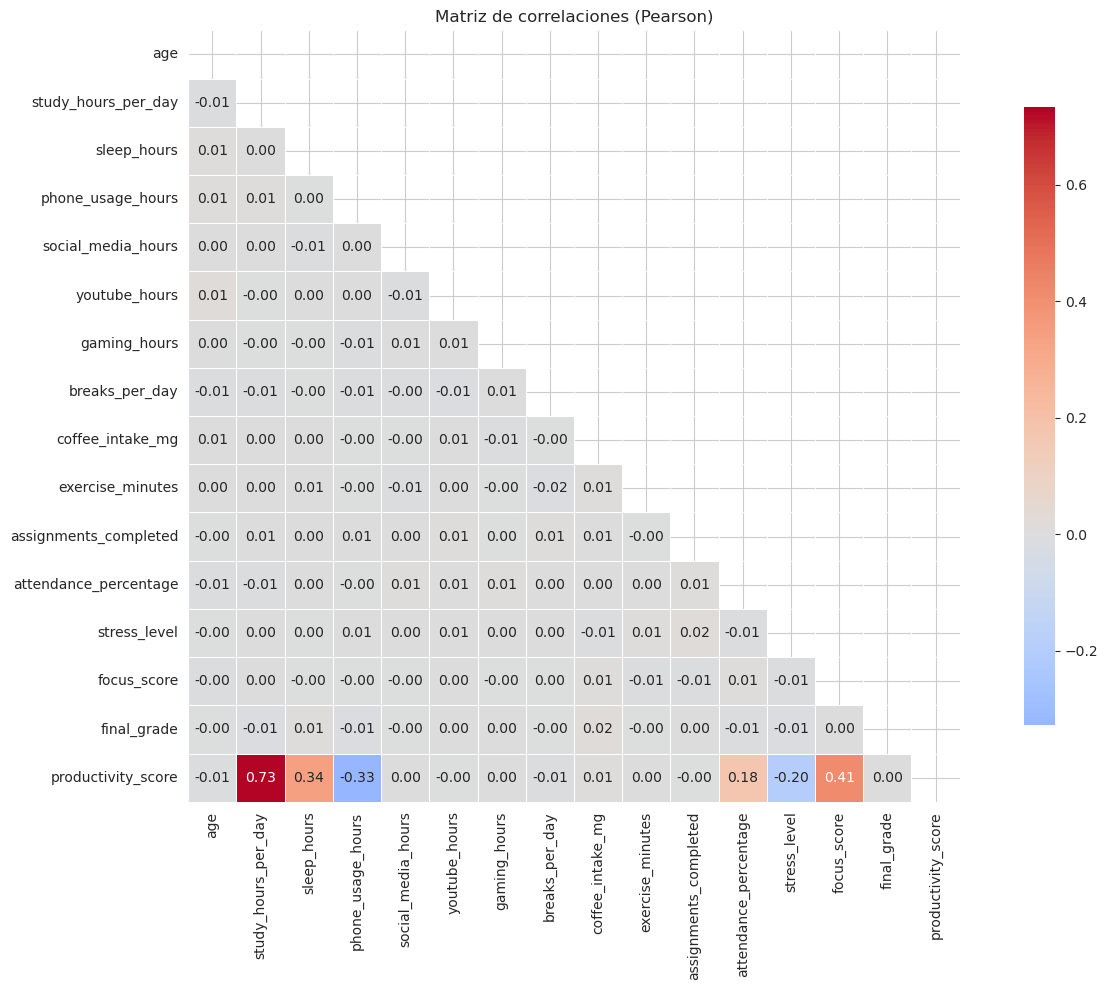

In [ ]:
plt.figure(figsize=(14, 10))
corr_matrix = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Matriz de correlaciones (Pearson)')
plt.tight_layout()
plt.show()

La gráfica revela que ninguna de las variables tiene una conexión lineal sólida con el nivel de estrés. Los valores están muy cerca de cero, salvo la puntuación de productividad que muestra una ligera relación inversa de menos cero punto veinte, lo cual sugiere que con más productividad, el estrés baja un poco, aunque la conexión permanece floja.

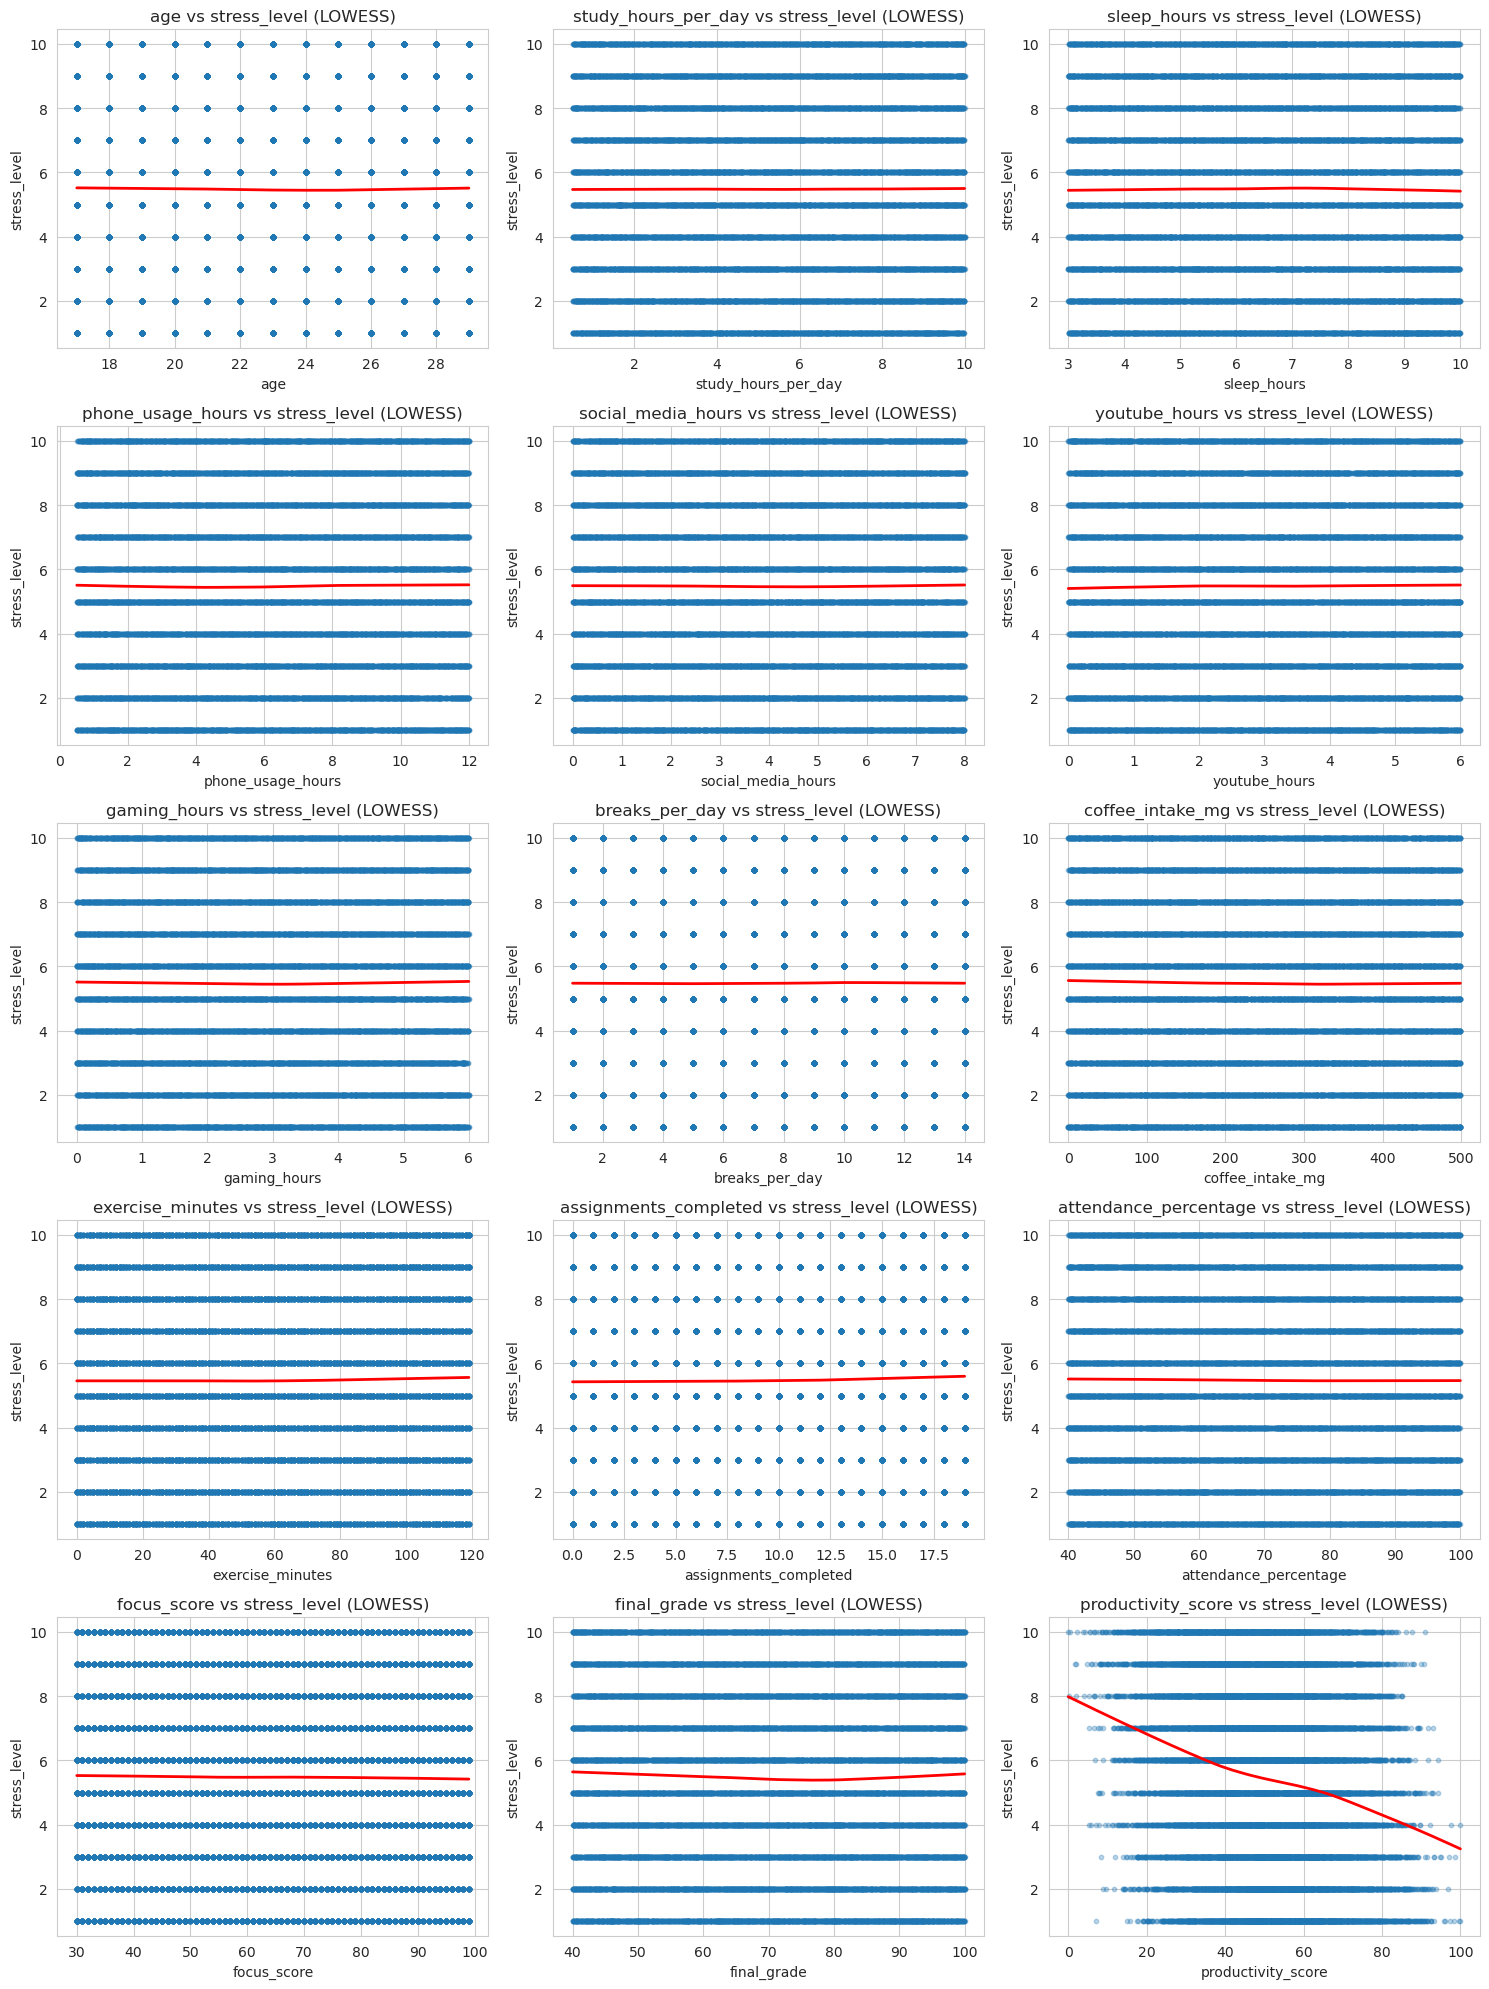

In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'student_id' in numeric_cols:
    numeric_cols.remove('student_id')
vars_to_plot = [col for col in numeric_cols if col != 'stress_level']

n_vars = len(vars_to_plot)
n_cols = 3
n_rows = (n_vars + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, var in enumerate(vars_to_plot):
    sns.regplot(data=df, x=var, y='stress_level', ax=axes[i],
                scatter_kws={'alpha':0.3, 's':10},
                line_kws={'color':'red', 'lw':2},
                lowess=True, ci=None)
    axes[i].set_title(f'{var} vs stress_level (LOWESS)')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('stress_level')

for i in range(n_vars, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [ ]:
duplicados = df.duplicated().sum()
display(f"Filas duplicadas: {duplicados}")

'Filas duplicadas: 0'

In [ ]:
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    print(f"\n{col}:")
    display(df[col].value_counts())


gender:


gender
Female    9640
Male      9582
Other      778
Name: count, dtype: int64

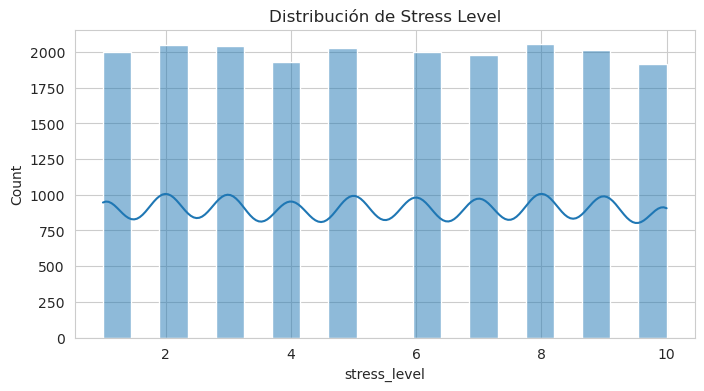

stress_level
1     1999
2     2050
3     2040
4     1932
5     2025
6     1996
7     1977
8     2053
9     2016
10    1912
Name: count, dtype: int64

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(df['stress_level'], bins=20, kde=True)
plt.title('Distribución de Stress Level')
plt.show()

display(df['stress_level'].value_counts().sort_index())